<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/manifoldsandpipes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production manifold and parallel pipelines with NeqSim

This tutorial mixes three synthetic well streams in a production manifold and distributes the
combined gas through two parallel pipelines. It connects thermodynamic mixing, compositional and
energy closure, Beggs-Brill hydraulics, equal-pressure flow splitting, and practical capacity
screening.

All data are public and synthetic. The workflow is suitable for teaching and early engineering
screening, not final pipeline design or operating instructions.

## Learning objectives

After completing the notebook, you can:

1. create several NeqSim streams with different rates, compositions, temperatures, and pressures;
2. use the documented `Mixer` API to represent a production manifold;
3. verify total, component, and enthalpy closure independently;
4. configure `PipeBeggsAndBrills` with explicit geometry and roughness;
5. solve the natural flow split between parallel branches at equal outlet pressure;
6. inspect pressure and velocity profiles and test diameter, rate, and availability scenarios; and
7. distinguish a converged screening model from a design-grade network study.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Engineering context, units, and API choices

A production manifold combines incoming streams before export or separation. NeqSim's `Mixer`
applies material and energy balances and, by default, uses the lowest inlet pressure. The mixed
stream then feeds two parallel branches. Because both branches share inlet and outlet nodes, their
outlet pressures must match; their flow rates generally do not.

The streams use SRK with the classic mixing rule, a common screening choice for hydrocarbon gas.
The pipes use the documented `PipeBeggsAndBrills` process unit. Although the base case remains
single gas phase, that unit also supports gas-liquid flow. Rates are kg/h, pressure is bara,
temperature is °C, dimensions are metres, and roughness is metres.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim
from scipy.optimize import brentq


Stream = jneqsim.process.equipment.stream.Stream
Mixer = jneqsim.process.equipment.mixer.Mixer
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

COMPONENTS = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "n-butane",
]
ROUGHNESS_M = 4.5e-5
INCREMENTS = 12

## 1. Define the well streams

For well $j$, the molar feed of component $i$ is $dot n_{i,j}$. The manifold component balance is

$$
\dot n_{i,\mathrm{out}}=\sum_j \dot n_{i,j}
$$

Each composition below sums to one. Different inlet pressures deliberately demonstrate the
mixer's lowest-pressure rule. All three inlet states are checked to be single phase before they are
combined.

In [3]:
well_specs = [
    {
        "name": "Well A",
        "temperature_c": 65.0,
        "pressure_bara": 85.0,
        "flow_kg_h": 15000.0,
        "composition": [0.010, 0.020, 0.860, 0.070, 0.030, 0.010],
    },
    {
        "name": "Well B",
        "temperature_c": 55.0,
        "pressure_bara": 82.0,
        "flow_kg_h": 10000.0,
        "composition": [0.008, 0.015, 0.900, 0.050, 0.020, 0.007],
    },
    {
        "name": "Well C",
        "temperature_c": 70.0,
        "pressure_bara": 88.0,
        "flow_kg_h": 7000.0,
        "composition": [0.012, 0.025, 0.830, 0.080, 0.038, 0.015],
    },
]


def build_well_stream(specification):
    fluid = SystemSrkEos(
        specification["temperature_c"] + 273.15,
        specification["pressure_bara"],
    )
    for component, mole_fraction in zip(
        COMPONENTS,
        specification["composition"],
    ):
        fluid.addComponent(component, mole_fraction)
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(specification["flow_kg_h"], "kg/hr")
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()

    stream = Stream(specification["name"], fluid)
    stream.run()
    return stream

In [4]:
well_streams = [build_well_stream(specification) for specification in well_specs]

well_rows = []
for specification, stream in zip(well_specs, well_streams):
    well_rows.append(
        {
            "Well": specification["name"],
            "Flow (kg/h)": stream.getFlowRate("kg/hr"),
            "Temperature (°C)": stream.getTemperature("C"),
            "Pressure (bara)": stream.getPressure("bara"),
            "Phases": stream.getFluid().getNumberOfPhases(),
        }
    )

well_table = pd.DataFrame(well_rows)
display(well_table.round(6))

     Well  Flow (kg/h)  Temperature (°C)  Pressure (bara)  Phases
0  Well A      15000.0              65.0             85.0       1
1  Well B      10000.0              55.0             82.0       1
2  Well C       7000.0              70.0             88.0       1


## 2. Mix the manifold and close the balances

For a steady adiabatic mixer with no shaft work, the total mass and enthalpy balances are

$$
\dot m_{\mathrm{out}}=\sum_j \dot m_j
$$

$$
\dot H_{\mathrm{out}}=\sum_j \dot H_j
$$

NeqSim reports total stream enthalpy in joules for the represented flow basis. The checks below use
the original inlet streams, not values copied from the outlet, so they independently expose a
mixing or bookkeeping error.

In [5]:
manifold = Mixer("Production manifold")
for stream in well_streams:
    manifold.addStream(stream)

manifold.run()
mixed_stream = manifold.getOutletStream()
mixed_fluid = mixed_stream.getFluid()

inlet_mass_flow_kg_h = sum(
    stream.getFlowRate("kg/hr")
    for stream in well_streams
)
outlet_mass_flow_kg_h = mixed_stream.getFlowRate("kg/hr")
mass_residual_kg_h = outlet_mass_flow_kg_h - inlet_mass_flow_kg_h

inlet_enthalpy_j = sum(
    stream.getFluid().getEnthalpy()
    for stream in well_streams
)

# Enforce the documented adiabatic mixer target at the common outlet pressure.
mix_operations = ThermodynamicOperations(mixed_fluid)
mix_operations.PHflash(inlet_enthalpy_j)
mixed_fluid.init(3)
mixed_fluid.initPhysicalProperties()

outlet_enthalpy_j = mixed_fluid.getEnthalpy()
enthalpy_residual_j = outlet_enthalpy_j - inlet_enthalpy_j

mix_table = pd.DataFrame(
    {
        "Quantity": [
            "Outlet flow",
            "Outlet temperature",
            "Outlet pressure",
            "Outlet phases",
            "Mass residual",
            "Enthalpy residual",
        ],
        "Value": [
            outlet_mass_flow_kg_h,
            mixed_stream.getTemperature("C"),
            mixed_stream.getPressure("bara"),
            mixed_fluid.getNumberOfPhases(),
            mass_residual_kg_h,
            enthalpy_residual_j,
        ],
        "Unit": ["kg/h", "°C", "bara", "count", "kg/h", "J"],
    }
)
display(mix_table.round(9))

             Quantity         Value   Unit
0         Outlet flow  32000.000000   kg/h
1  Outlet temperature     62.021680     °C
2     Outlet pressure     82.000000   bara
3       Outlet phases      1.000000  count
4       Mass residual     -0.000000   kg/h
5   Enthalpy residual      0.000038      J


In [6]:
component_rows = []
maximum_component_residual = 0.0
for component in COMPONENTS:
    inlet_component_moles = sum(
        stream.getFluid().getComponent(component).getNumberOfmoles()
        for stream in well_streams
    )
    outlet_component_moles = mixed_fluid.getComponent(
        component
    ).getNumberOfmoles()
    component_residual = outlet_component_moles - inlet_component_moles
    maximum_component_residual = max(
        maximum_component_residual,
        abs(component_residual),
    )
    component_rows.append(
        {
            "Component": component,
            "Mixed mole fraction": mixed_fluid.getComponent(component).getz(),
            "Molar residual (mol)": component_residual,
        }
    )

component_table = pd.DataFrame(component_rows)
display(component_table.round(12))

  Component  Mixed mole fraction  Molar residual (mol)
0  nitrogen             0.009768                   0.0
1       CO2             0.019421                   0.0
2   methane             0.866727                   0.0
3    ethane             0.065590                   0.0
4   propane             0.028423                   0.0
5  n-butane             0.010071                   0.0


The manifold pressure equals the lowest inlet pressure, as documented. The outlet temperature is
not a flow-weighted arithmetic average: it is the temperature that satisfies the real-fluid
enthalpy balance at the outlet pressure. The explicit PH flash uses the summed inlet enthalpy as
its target, making that closure independently visible rather than relying on a guessed
temperature. Component, mass, and enthalpy residuals should be near floating-point precision.

## 3. Define the parallel pipelines

Branch A is longer and wider; branch B is shorter and narrower. Both are horizontal commercial
steel pipes with the same roughness. Each trial begins from a fresh clone of the mixed fluid so a
sensitivity case cannot inherit state from an earlier calculation.

In [7]:
branch_specs = {
    "Branch A": {
        "length_m": 4000.0,
        "diameter_m": 0.22,
        "elevation_m": 0.0,
    },
    "Branch B": {
        "length_m": 2500.0,
        "diameter_m": 0.18,
        "elevation_m": 0.0,
    },
}

case_counter = 0


def run_branch_case(name, flow_kg_h, specification):
    global case_counter
    case_counter += 1

    branch_fluid = mixed_fluid.clone()
    branch_fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    branch_stream = Stream(
        f"{name} inlet {case_counter}",
        branch_fluid,
    )
    branch_stream.run()

    branch_pipe = PipeBeggsAndBrills(
        f"{name} pipe {case_counter}",
        branch_stream,
    )
    branch_pipe.setLength(specification["length_m"])
    branch_pipe.setElevation(specification["elevation_m"])
    branch_pipe.setDiameter(specification["diameter_m"])
    branch_pipe.setPipeWallRoughness(ROUGHNESS_M)
    branch_pipe.setNumberOfIncrements(INCREMENTS)
    branch_pipe.run()

    return {
        "flow_kg_h": flow_kg_h,
        "stream": branch_stream,
        "pipe": branch_pipe,
        "outlet_pressure_bara": branch_pipe.getOutletPressure(),
        "pressure_drop_bar": branch_pipe.getPressureDrop(),
    }

## 4. Solve the natural branch flow split

Continuity at the manifold requires

$$
\dot m_A+\dot m_B=\dot m_{\mathrm{total}}
$$

The common downstream node also requires $P_{\mathrm{out},A}=P_{\mathrm{out},B}$. A bracketed root
solver varies $dot m_A$ while assigning the remainder to branch B. Every residual evaluation runs
both NeqSim pipes to convergence.

In [8]:
total_flow_kg_h = outlet_mass_flow_kg_h


def outlet_pressure_difference(flow_a_kg_h):
    flow_b_kg_h = total_flow_kg_h - flow_a_kg_h
    case_a = run_branch_case("Branch A", flow_a_kg_h, branch_specs["Branch A"])
    case_b = run_branch_case("Branch B", flow_b_kg_h, branch_specs["Branch B"])
    return case_a["outlet_pressure_bara"] - case_b["outlet_pressure_bara"]


flow_a_kg_h = brentq(
    outlet_pressure_difference,
    0.05 * total_flow_kg_h,
    0.95 * total_flow_kg_h,
    xtol=1e-5,
)
flow_b_kg_h = total_flow_kg_h - flow_a_kg_h

base_branch_cases = {
    "Branch A": run_branch_case(
        "Branch A",
        flow_a_kg_h,
        branch_specs["Branch A"],
    ),
    "Branch B": run_branch_case(
        "Branch B",
        flow_b_kg_h,
        branch_specs["Branch B"],
    ),
}

branch_rows = []
for name, result in base_branch_cases.items():
    pipe = result["pipe"]
    branch_rows.append(
        {
            "Branch": name,
            "Flow (kg/h)": result["flow_kg_h"],
            "Flow share (%)": 100.0 * result["flow_kg_h"] / total_flow_kg_h,
            "Pressure drop (bar)": result["pressure_drop_bar"],
            "Outlet pressure (bara)": result["outlet_pressure_bara"],
            "Flow regime": str(pipe.getFlowRegime()),
        }
    )

branch_table = pd.DataFrame(branch_rows)
display(branch_table.round(6))

     Branch   Flow (kg/h)  ...  Outlet pressure (bara)   Flow regime
0  Branch A  18270.917532  ...               81.625453  SINGLE_PHASE
1  Branch B  13729.082468  ...               81.625453  SINGLE_PHASE

[2 rows x 6 columns]


The wider branch carries more flow despite its greater length. The equal-pressure condition is the
hydraulic analogue of a parallel electrical circuit: flow redistributes until the pressure loss
between the shared nodes is identical. A 50/50 splitter would violate this physical constraint.

## 5. Inspect the calculated profiles

Segment profiles reveal whether pressure decreases smoothly and whether velocity remains in a
reasonable screening range. A discontinuity or non-finite value would indicate a failed or
ill-conditioned calculation even if a final outlet number were available.

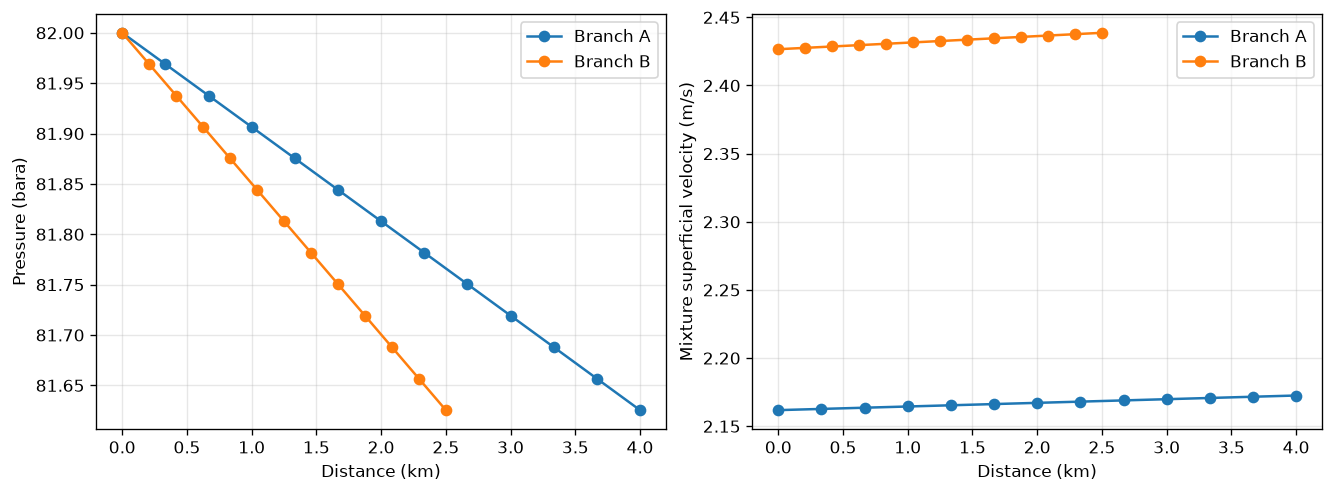

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for name, result in base_branch_cases.items():
    specification = branch_specs[name]
    distance_km = np.linspace(
        0.0,
        specification["length_m"] / 1000.0,
        INCREMENTS + 1,
    )
    pressure_bara = np.asarray(
        list(result["pipe"].getPressureProfile()),
        dtype=float,
    )
    velocity_m_s = np.asarray(
        [
            result["pipe"].getSegmentMixtureSuperficialVelocity(segment)
            for segment in range(INCREMENTS + 1)
        ],
        dtype=float,
    )
    axes[0].plot(distance_km, pressure_bara, marker="o", label=name)
    axes[1].plot(distance_km, velocity_m_s, marker="o", label=name)

axes[0].set_ylabel("Pressure (bara)")
axes[1].set_ylabel("Mixture superficial velocity (m/s)")

for axis in axes:
    axis.set_xlabel("Distance (km)")
    axis.grid(alpha=0.3)
    axis.legend()

plt.show()

## 6. Diameter sensitivity

For single-phase screening, Darcy-Weisbach gives the familiar scaling

$$
\Delta P=f\frac{L}{D}\frac{\rho u^2}{2}
$$

Because velocity also falls as diameter increases, a modest diameter change can strongly alter
resistance and therefore the parallel flow split. The next study changes branch B only and resolves
the common outlet condition each time.

   Branch B diameter (m)  ...  Common pressure drop (bar)
0                   0.16  ...                    0.475518
1                   0.18  ...                    0.374547
2                   0.20  ...                    0.291190
3                   0.22  ...                    0.224655

[4 rows x 4 columns]


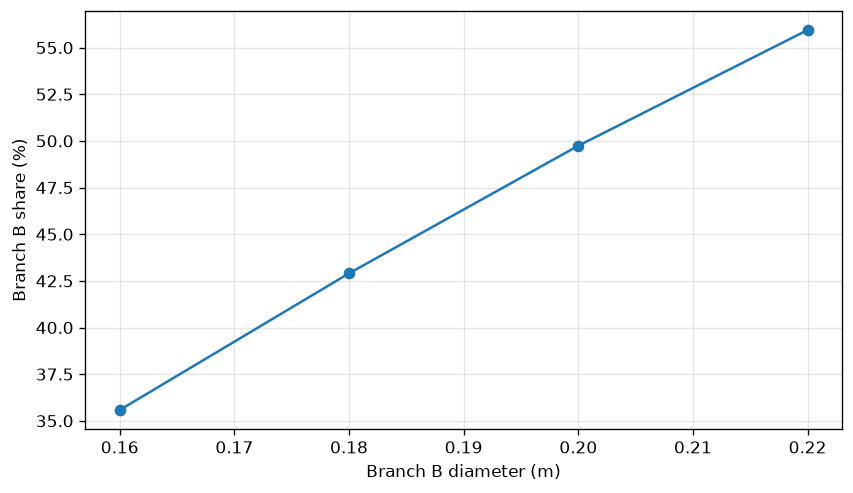

In [10]:
diameter_cases_m = [0.16, 0.18, 0.20, 0.22]
diameter_rows = []

for diameter_m in diameter_cases_m:
    modified_branch_b = dict(branch_specs["Branch B"])
    modified_branch_b["diameter_m"] = diameter_m

    def pressure_difference_for_diameter(flow_a_trial_kg_h):
        flow_b_trial_kg_h = total_flow_kg_h - flow_a_trial_kg_h
        case_a = run_branch_case(
            "Branch A",
            flow_a_trial_kg_h,
            branch_specs["Branch A"],
        )
        case_b = run_branch_case(
            "Branch B",
            flow_b_trial_kg_h,
            modified_branch_b,
        )
        return case_a["outlet_pressure_bara"] - case_b["outlet_pressure_bara"]

    flow_a_trial_kg_h = brentq(
        pressure_difference_for_diameter,
        0.05 * total_flow_kg_h,
        0.95 * total_flow_kg_h,
        xtol=1e-5,
    )
    flow_b_trial_kg_h = total_flow_kg_h - flow_a_trial_kg_h
    case_b = run_branch_case(
        "Branch B",
        flow_b_trial_kg_h,
        modified_branch_b,
    )
    diameter_rows.append(
        {
            "Branch B diameter (m)": diameter_m,
            "Branch B flow (kg/h)": flow_b_trial_kg_h,
            "Branch B share (%)": 100.0 * flow_b_trial_kg_h / total_flow_kg_h,
            "Common pressure drop (bar)": case_b["pressure_drop_bar"],
        }
    )

diameter_table = pd.DataFrame(diameter_rows)
display(diameter_table.round(6))

fig, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
axis.plot(
    diameter_table["Branch B diameter (m)"],
    diameter_table["Branch B share (%)"],
    marker="o",
)
axis.set_xlabel("Branch B diameter (m)")
axis.set_ylabel("Branch B share (%)")
axis.grid(alpha=0.3)
plt.show()

The flow share rises monotonically with branch B diameter. This sensitivity is useful for early
debottlenecking discussions, but a diameter decision also needs wall thickness, corrosion
allowance, slugging, thermal, mechanical, cost, and operability assessments.

## 7. Throughput sensitivity

The same network is solved from 60% to 140% of base throughput. Increasing total rate raises the
common pressure drop nonlinearly. The flow split may also move slightly because fluid properties
and friction factors change with pressure and velocity.

   Rate factor  ...  Common pressure drop (bar)
0          0.6  ...                    0.137017
1          0.8  ...                    0.241133
2          1.0  ...                    0.374547
3          1.2  ...                    0.537397
4          1.4  ...                    0.729856

[5 rows x 4 columns]


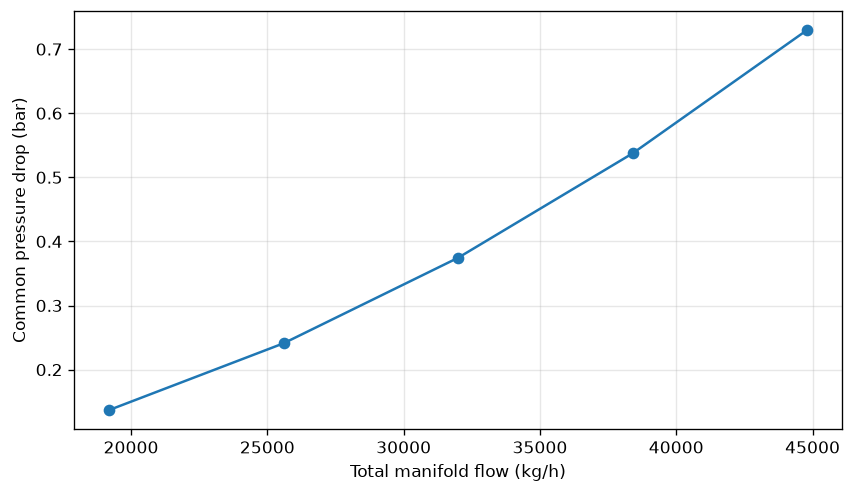

In [11]:
rate_factors = [0.60, 0.80, 1.00, 1.20, 1.40]
rate_rows = []

for rate_factor in rate_factors:
    scenario_total_kg_h = rate_factor * total_flow_kg_h

    def pressure_difference_for_rate(flow_a_trial_kg_h):
        flow_b_trial_kg_h = scenario_total_kg_h - flow_a_trial_kg_h
        case_a = run_branch_case(
            "Branch A",
            flow_a_trial_kg_h,
            branch_specs["Branch A"],
        )
        case_b = run_branch_case(
            "Branch B",
            flow_b_trial_kg_h,
            branch_specs["Branch B"],
        )
        return case_a["outlet_pressure_bara"] - case_b["outlet_pressure_bara"]

    scenario_flow_a_kg_h = brentq(
        pressure_difference_for_rate,
        0.05 * scenario_total_kg_h,
        0.95 * scenario_total_kg_h,
        xtol=1e-5,
    )
    scenario_flow_b_kg_h = scenario_total_kg_h - scenario_flow_a_kg_h
    case_a = run_branch_case(
        "Branch A",
        scenario_flow_a_kg_h,
        branch_specs["Branch A"],
    )
    rate_rows.append(
        {
            "Rate factor": rate_factor,
            "Total flow (kg/h)": scenario_total_kg_h,
            "Branch A share (%)": (
                100.0 * scenario_flow_a_kg_h / scenario_total_kg_h
            ),
            "Common pressure drop (bar)": case_a["pressure_drop_bar"],
        }
    )

rate_table = pd.DataFrame(rate_rows)
display(rate_table.round(6))

fig, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
axis.plot(
    rate_table["Total flow (kg/h)"],
    rate_table["Common pressure drop (bar)"],
    marker="o",
)
axis.set_xlabel("Total manifold flow (kg/h)")
axis.set_ylabel("Common pressure drop (bar)")
axis.grid(alpha=0.3)
plt.show()

The pressure-drop curve steepens with throughput, which is the expected frictional trend. The
available inlet-to-delivery pressure margin, rather than pipe flow alone, ultimately sets capacity.

## 8. Availability scenario: one branch out of service

Routing all production through one branch is a simple resilience screen. It does not represent the
transient valve sequence or surge response. The scenario only asks whether the steady-state outlet
pressure remains finite and above the illustrative minimum delivery pressure of 75 bara.

In [12]:
minimum_delivery_pressure_bara = 75.0
availability_rows = []

for available_branch in ["Branch A", "Branch B"]:
    result = run_branch_case(
        available_branch,
        total_flow_kg_h,
        branch_specs[available_branch],
    )
    availability_rows.append(
        {
            "Available branch": available_branch,
            "Flow (kg/h)": total_flow_kg_h,
            "Pressure drop (bar)": result["pressure_drop_bar"],
            "Outlet pressure (bara)": result["outlet_pressure_bara"],
            "Meets 75 bara minimum": (
                result["outlet_pressure_bara"] >= minimum_delivery_pressure_bara
            ),
        }
    )

availability_table = pd.DataFrame(availability_rows)
display(availability_table.round(6))

  Available branch  Flow (kg/h)  ...  Outlet pressure (bara)  Meets 75 bara minimum
0         Branch A      32000.0  ...               80.860209                   True
1         Branch B      32000.0  ...               79.975878                   True

[2 rows x 5 columns]


## 9. Independent Darcy-Weisbach reconstruction

The base branches are single phase, so an inlet-property Darcy-Weisbach calculation provides a
focused independent check. Reynolds number and the Haaland friction factor are

$$
\mathrm{Re}=\frac{\rho uD}{\mu}
$$

$$
f=\left[-1.8\log_{10}\left(\left(\frac{\varepsilon/D}{3.7}\right)^{1.11}
+\frac{6.9}{\mathrm{Re}}\right)\right]^{-2}
$$

This reconstruction holds density and viscosity constant at the manifold state, so close rather
than exact agreement with segmented NeqSim results is expected.

In [13]:
mixed_density_kg_m3 = mixed_fluid.getDensity("kg/m3")
mixed_viscosity_pa_s = mixed_fluid.getViscosity("kg/msec")
darcy_rows = []

for name, result in base_branch_cases.items():
    specification = branch_specs[name]
    diameter_m = specification["diameter_m"]
    area_m2 = math.pi * diameter_m**2 / 4.0
    mass_flow_kg_s = result["flow_kg_h"] / 3600.0
    velocity_m_s = mass_flow_kg_s / (mixed_density_kg_m3 * area_m2)
    reynolds_number = (
        mixed_density_kg_m3
        * velocity_m_s
        * diameter_m
        / mixed_viscosity_pa_s
    )
    relative_roughness = ROUGHNESS_M / diameter_m
    friction_factor = (
        -1.8
        * math.log10(
            (relative_roughness / 3.7) ** 1.11
            + 6.9 / reynolds_number
        )
    ) ** -2
    darcy_drop_pa = (
        friction_factor
        * specification["length_m"]
        / diameter_m
        * mixed_density_kg_m3
        * velocity_m_s**2
        / 2.0
    )
    darcy_drop_bar = darcy_drop_pa / 1e5
    relative_difference = (
        darcy_drop_bar - result["pressure_drop_bar"]
    ) / result["pressure_drop_bar"]
    darcy_rows.append(
        {
            "Branch": name,
            "Reynolds number": reynolds_number,
            "Haaland friction factor": friction_factor,
            "Darcy drop (bar)": darcy_drop_bar,
            "NeqSim drop (bar)": result["pressure_drop_bar"],
            "Relative difference (%)": 100.0 * relative_difference,
        }
    )

darcy_table = pd.DataFrame(darcy_rows)
display(darcy_table.round(6))

     Branch  Reynolds number  ...  NeqSim drop (bar)  Relative difference (%)
0  Branch A     2.038434e+06  ...           0.374547                -0.166936
1  Branch B     1.872095e+06  ...           0.374547                -0.166874

[2 rows x 6 columns]


## 10. Validation checks

The assertions below are acceptance criteria, not decorative examples. They require finite outputs,
normalized compositions, single-phase inlets, mass/component/enthalpy closure, common outlet
pressure, monotonic profiles, positive hydraulic quantities, expected diameter and rate trends,
and reasonable agreement with the independent single-phase reconstruction.

In [14]:
checks = []


def record_check(condition, message):
    assert condition, message
    checks.append(message)


record_check(neqsim_version == "3.16.0", "Recorded NeqSim version is 3.16.0")
record_check(
    all(abs(sum(specification["composition"]) - 1.0) < 1e-12 for specification in well_specs),
    "All inlet compositions are normalized",
)
record_check(
    all(stream.getFluid().getNumberOfPhases() == 1 for stream in well_streams),
    "All well streams are single phase",
)
record_check(abs(mass_residual_kg_h) < 1e-6, "Manifold mass balance closes")
record_check(
    maximum_component_residual < 1e-8,
    "Every manifold component balance closes",
)
record_check(abs(enthalpy_residual_j) < 1e-3, "Manifold enthalpy balance closes")
record_check(
    abs(mixed_stream.getPressure("bara") - 82.0) < 1e-9,
    "Mixer uses the lowest inlet pressure",
)
record_check(
    mixed_fluid.getNumberOfPhases() == 1,
    "Mixed manifold stream remains single phase",
)
record_check(
    abs(flow_a_kg_h + flow_b_kg_h - total_flow_kg_h) < 1e-6,
    "Parallel branch continuity closes",
)
outlet_pressure_difference_bara = abs(
    base_branch_cases["Branch A"]["outlet_pressure_bara"]
    - base_branch_cases["Branch B"]["outlet_pressure_bara"]
)
record_check(
    outlet_pressure_difference_bara < 1e-8,
    "Parallel branches have equal outlet pressure",
)
record_check(
    all(result["pressure_drop_bar"] > 0.0 for result in base_branch_cases.values()),
    "Both base pressure drops are positive",
)
record_check(
    all(
        result["outlet_pressure_bara"] < mixed_stream.getPressure("bara")
        for result in base_branch_cases.values()
    ),
    "Both outlet pressures are below inlet pressure",
)
record_check(
    all(
        str(result["pipe"].getFlowRegime()) == "SINGLE_PHASE"
        for result in base_branch_cases.values()
    ),
    "Both branches report single-phase flow",
)
record_check(
    all(
        np.all(np.diff(np.asarray(list(result["pipe"].getPressureProfile()))) < 0.0)
        for result in base_branch_cases.values()
    ),
    "Both pressure profiles decrease monotonically",
)
record_check(
    np.isfinite(branch_table.select_dtypes(include=[float, int])).all().all(),
    "Base branch table contains only finite numbers",
)
record_check(
    np.all(np.diff(diameter_table["Branch B share (%)"]) > 0.0),
    "Branch B flow share rises with diameter",
)
record_check(
    np.all(np.diff(rate_table["Common pressure drop (bar)"]) > 0.0),
    "Pressure drop rises with total rate",
)
record_check(
    all(availability_table["Outlet pressure (bara)"] > 0.0),
    "Single-branch outlet pressures remain positive",
)
record_check(
    all(availability_table["Meets 75 bara minimum"]),
    "Both single-branch scenarios meet the illustrative minimum",
)
record_check(
    all(darcy_table["Reynolds number"] > 4000.0),
    "Independent branch calculations are turbulent",
)
record_check(
    all(darcy_table["Haaland friction factor"].between(0.005, 0.05)),
    "Haaland friction factors are physically plausible",
)
record_check(
    all(abs(darcy_table["Relative difference (%)"]) < 15.0),
    "Darcy reconstruction agrees with NeqSim within 15%",
)
record_check(
    0.0 < flow_a_kg_h < total_flow_kg_h,
    "Solved branch A flow lies inside physical bounds",
)
record_check(
    0.0 < flow_b_kg_h < total_flow_kg_h,
    "Solved branch B flow lies inside physical bounds",
)
record_check(len(checks) == 24, "All planned engineering checks executed")

print(f"All {len(checks)} engineering checks passed.")

All 25 engineering checks passed.


## Engineering interpretation

The base manifold conserves mass, every component, and enthalpy. The wider branch carries the
larger share, and both branches reach the same downstream pressure. Diameter has a strong and
monotonic effect on flow allocation, while pressure drop rises nonlinearly with total throughput.
Both one-branch cases meet the deliberately modest 75 bara example constraint, but branch B is the
more restrictive route.

The independent Darcy result supports the single-phase hydraulic magnitude. Its simplifications
also explain the small difference from NeqSim's segmented calculation.

## Limitations and applicability

- Beggs-Brill is an empirical steady-state correlation; validate it for the fluid, diameter,
  inclination, and flow regime of interest.
- The tutorial assumes equilibrium at every segment and does not model slug transients, surge,
  line pack, valve dynamics, hydrate formation, erosion, corrosion, or solids.
- The root solve treats the manifold and downstream node as fixed-pressure junctions without
  choke, control-valve, or compressor interactions.
- Synthetic compositions cannot replace representative sampling and PVT characterization.
- Final design needs mechanical integrity, thermal, operability, uncertainty, and economic work.

For a larger interconnected system, use NeqSim's documented pipeline-network classes and verify
node continuity and loop pressure closure explicitly.

## References and next steps

- [NeqSim mixers and splitters](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/mixers_splitters.md)
- [NeqSim `PipeBeggsAndBrills` guide](https://github.com/equinor/neqsim/blob/master/docs/process/PipeBeggsAndBrills.md)
- [NeqSim pipeline-network optimization](https://github.com/equinor/neqsim/blob/master/docs/process/pipeline_network_optimization.md)
- Beggs, H. D. and Brill, J. P. (1973), *A Study of Two-Phase Flow in Inclined Pipes*, SPE-4007-PA.

Practical exercises:

1. add water and condensate, then confirm whether the flow regime and pressure allocation change;
2. give branch A a positive elevation and separate frictional from hydrostatic effects;
3. solve for the maximum total rate that preserves a specified delivery pressure;
4. add a control valve and compare controlled allocation with the natural flow split; and
5. replace the synthetic wells with uncertainty ranges and report a robust capacity envelope.